In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
UCL_AllTime =pd.read_csv('/kaggle/input/datasets/devyammalhotra/ucl-dataset/UCL_AllTime_Performance_Table.csv')
UCL_Finals =pd.read_csv('/kaggle/input/datasets/devyammalhotra/ucl-dataset/UCL_Finals_1955-2023.csv')

###1. Data Summary

#### `UCL_AllTime` DataFrame
This DataFrame, named `UCL_AllTime`, contains the historical performance records of teams in the UEFA Champions League. It shows how each team has performed across all seasons, including matches played, wins, draws, losses, goal statistics, goal difference, and total points. It has 354 entries, one for each team.

#### `UCL_Finals` DataFrame
This DataFrame, named `UCL_Finals`, lists the results of all UEFA Champions League finals from the 1955–56 season up to 2023. It includes details such as the season, the winning country, the winning team, the final score, and the runner-up team. There are 69 entries in this dataset, corresponding to each final match.

It's worth noting that the `UCL_Finals` DataFrame appears to have some empty rows at the end which may need to be addressed.

###2. Column Descriptions

#### `UCL_AllTime` Table
*   **`#`**: The rank of the team in the all-time performance table.
*   **`Team`**: The name of the football club.
*   **`M.`**: The total number of matches played by the team.
*   **`W`**: The total number of matches won by the team.
*   **`D`**: The total number of matches drawn (tied) by the team.
*   **`L`**: The total number of matches lost by the team.
*   **`goals`**: Goal statistics, likely representing goals scored and conceded.
*   **`Dif`**: The goal difference (goals scored minus goals conceded).
*   **`Pt.`**: The total points accumulated by the team.

#### `UCL_Finals` Table
*   **`Season`**: The football season when the final match took place.
*   **`Country`**: The country of the winning team.
*   **`Winners`**: The name of the team that won the final.
*   **`Score`**: The final score of the match.
*   **`Runners-up`**: The name of the team that lost the final.
*   **`Venue`**: The stadium where the final was played.
*   **`Location`**: The city and country where the final venue is located.
*   **`Attendance`**: The number of spectators at the final match.
*   **`Notes`**: Any additional notes or remarks about the final.

In [3]:
# Exporting data for Manual Assessment

with pd.ExcelWriter('Ucl_Analysis.xlsx') as Writer:
  UCL_AllTime.to_excel(Writer,sheet_name='UCL_AllTime')
  UCL_Finals.to_excel(Writer,sheet_name='UCL_Finals')


Issues with the dataset

`UCL_AllTime` Table
```
- We need to Rename the columns for Clarity `Tidiness`
- Ranks column named # has 21 missing values `Completeness`
- Here goals scored By the team and scored against the team are in a single column `Tidiness`
- Here the values of goals scored against the team is inaccurate ` Accuracy`
- Here Pt column is just a duplicate of Dif column `Tidiness`
```
`UCL_Finals` Table
```
- We need to split the values of Score column into 2 different ones `Tidiness`
- Attend column needs to be numerical `Validity`
- There are 51 missing values in notes column `Completeness`
- There are 2 entries for the season 1973-1974 `validity`
```


In [4]:
# Automatic Assessment

UCL_AllTime.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   #       333 non-null    float64
 1   Team    354 non-null    object 
 2   M.      354 non-null    int64  
 3   W       354 non-null    int64  
 4   D       354 non-null    int64  
 5   L       354 non-null    int64  
 6   goals   354 non-null    object 
 7   Dif     354 non-null    int64  
 8   Pt.     354 non-null    int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 25.0+ KB


In [5]:
UCL_AllTime[UCL_AllTime['#'].isnull( )]

,#,Team,M.,W,D,L,goals,Dif,Pt.
110,NaN,Servette FC,17,6,4,7,27:30:00,-3,-3
199,NaN,FC Sheriff,6,2,1,3,7:11,-4,-4
210,NaN,Eintracht Braunschweig,5,2,0,3,5:5,0,0
230,NaN,Spartak Plovdiv,4,1,1,2,3:3,0,0
251,NaN,KA Akureyri,2,1,0,1,1:3,-2,-2
255,NaN,Szombierki Bytom,4,1,0,3,4:7,-3,-3
282,NaN,Skeid Fotball,2,0,1,1,1:2,-1,-1
284,NaN,FC Admira Wacker,2,0,1,1,0:1,-1,-1
286,NaN,PFC Beroe,2,0,1,1,1:3,-2,-2
290,NaN,St Patrick's Athletic,2,0,1,1,1:5,-4,-4


In [6]:
UCL_AllTime.duplicated(subset='Team').sum( )

np.int64(0)

In [7]:
UCL_AllTime.describe( )

,#,M.,W,D,L,Dif,Pt.
count,333.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000
mean,170.768769,33.254237,13.039548,7.169492,13.039548,0.000000,0.000000
std,100.863698,61.581865,31.468472,13.729255,18.669137,52.566267,52.566267
min,1.000000,2.000000,0.000000,0.000000,0.000000,-97.000000,-97.000000
25%,84.000000,4.000000,0.000000,0.000000,2.000000,-14.000000,-14.000000
50%,168.000000,8.000000,2.000000,2.000000,5.000000,-5.000000,-5.000000
75%,255.000000,31.500000,9.000000,6.000000,14.000000,0.000000,0.000000
max,354.000000,486.000000,291.000000,85.000000,110.000000,533.000000,533.000000


In [8]:
UCL_Finals.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Season       69 non-null     object
 1   Country      69 non-null     object
 2   Winners      69 non-null     object
 3   Score        69 non-null     object
 4   Runners-up   69 non-null     object
 5   Country.1    69 non-null     object
 6   Venue        69 non-null     object
 7   Attend­ance  69 non-null     object
 8   Notes        18 non-null     object
dtypes: object(9)
memory usage: 5.0+ KB


In [9]:
UCL_Finals[UCL_Finals['Notes'].isnull( )]

,Season,Country,Winners,Score,Runners-up,Country.1,Venue,Attend­ance,Notes
0,1955–56,Spain,Real Madrid,4–3,Reims,France,"Parc des Princes, Paris, France","38,239",NaN
1,1956–57,Spain,Real Madrid,2–0,Fiorentina,Italy,"Santiago Bernabéu, Madrid, Spain","124,000",NaN
3,1958–59,Spain,Real Madrid,2–0,Reims,France,"Neckarstadion, Stuttgart, West Germany","72,000",NaN
4,1959–60,Spain,Real Madrid,7–3,Eintracht Frankfurt,West Germany,"Hampden Park, Glasgow, Scotland","127,621",NaN
5,1960–61,Portugal,SL Benfica,3–2,FC Barcelona,Spain,"Wankdorf Stadium, Bern, Switzerland","26,732",NaN
6,1961–62,Portugal,SL Benfica,5–3,Real Madrid,Spain,"Olympisch Stadion, Amsterdam, Netherlands","61,257",NaN
7,1962–63,Italy,AC Milan,2–1,SL Benfica,Portugal,"Wembley Stadium, London, England","45,715",NaN
8,1963–64,Italy,Inter Milan,3–1,Real Madrid,Spain,"Praterstadion, Vienna, Austria","71,333",NaN
9,1964–65,Italy,Inter Milan,1–0,SL Benfica,Portugal,"San Siro, Milan, Italy","89,000",NaN
10,1965–66,Spain,Real Madrid,2–1,Partizan,Yugoslavia,"Heysel Stadium, Brussels, Belgium","46,745",NaN


In [10]:
UCL_Finals[UCL_Finals.duplicated(subset='Season')]

,Season,Country,Winners,Score,Runners-up,Country.1,Venue,Attend­ance,Notes
19,1973–74,West Germany,Bayern Munich,4–0,Atlético Madrid,Spain,"Heysel Stadium, Brussels, Belgium","23,325",Match was won after a replay


In [11]:
UCL_Finals.describe( )

,Season,Country,Winners,Score,Runners-up,Country.1,Venue,Attend­ance,Notes
count,69,69,69,69,69,69,69,69,18
unique,68,11,23,14,36,14,34,66,3
top,1973–74,Spain,Real Madrid,1–0,Juventus,Italy,"Wembley Stadium, London, England","70,000",Match was won on a penalty shoot-out
freq,2,19,14,19,7,17,7,3,11


Data Cleaning

In [12]:
UCL_AllTime_df=UCL_AllTime.copy( )
UCL_Finals_df=UCL_Finals.copy( )

 Completeness Issue

In [13]:

# Filling all the missing ranks and changing there data type
UCL_AllTime_df['#']=UCL_AllTime_df['#'].interpolate(method='linear',limit_direction='forward')
UCL_AllTime_df['#']=UCL_AllTime_df['#'].astype(int)

# Filling all the missing values in Notes column
UCL_Finals_df['Notes']=UCL_Finals_df['Notes'].fillna('Match was won in regulation time')


Tidiness Issue

In [14]:

# Renaming the columns
UCL_AllTime_df=UCL_AllTime_df.rename(columns={'#':'Rank','M.':'Matches','W':'Wins','D':'Draws','L':'Losses','Dif':'Goal_Difference','Pt.':'Points'})

# Creating 2 columns Goals_scored and Goals_conceded instead of single column Goals

UCL_AllTime_df['Goals_scored']=UCL_AllTime_df['goals'].str.split(':').str.get(0).astype(int)
UCL_AllTime_df['Goals_conceded']=UCL_AllTime_df['goals'].str.split(':').str.get(1).astype(int)

# Droping the Goals column
UCL_AllTime_df.drop('goals', axis=1, inplace=True)




In [15]:

# Splitting the Score column into Winner_Goals and Runnersup_Goals columns
UCL_Finals_df['Winner_Goals'] = UCL_Finals_df['Score'].str.split('–').str.get(0).astype(int)
UCL_Finals_df['Runnersup_Goals'] = UCL_Finals_df['Score'].str.split('–').str.get(1).astype(int)

# Droping the Score column
UCL_Finals_df.drop('Score',axis=1,inplace=True)


Validity Issue

In [16]:

# Converting the type of Attendance column to numerical
UCL_Finals_df['Attend­ance'] = UCL_Finals_df['Attend­ance'].astype(str).str.replace(',', '').astype(int)

In [17]:

# Removing the duplicate entry for 1973-1974 Season
UCL_Finals_df=UCL_Finals_df.drop_duplicates(subset='Season')


In [18]:

# Also correcting the final score to 4-0 in respective winner and runners up column
UCL_Finals_df.loc[18, 'Winner_Goals'] = 4
UCL_Finals_df.loc[18, 'Runnersup_Goals'] = 0



Accuracy Issue

In [19]:

# Correcting the Goals_conceded column
UCL_AllTime_df['Goals_conceded']=UCL_AllTime_df['Goals_scored']-UCL_AllTime_df['Goal_Difference']


Cleaned-up Dataframes

In [20]:
UCL_AllTime_df

,Rank,Team,Matches,Wins,Draws,Losses,Goal_Difference,Points,Goals_scored,Goals_conceded
0,1,Real Madrid,486,291,85,110,533,533,1076,543
1,2,Bayern Munich,388,231,78,79,427,427,817,390
2,3,FC Barcelona,341,196,77,68,319,319,675,356
3,4,Manchester United,289,153,69,67,224,224,524,300
4,5,Juventus,297,151,68,78,171,171,472,301
...,...,...,...,...,...,...,...,...,...,...
349,350,KR Reykjavík,6,0,0,6,-28,-28,7,35
350,351,Keflavík ÍF,8,0,0,8,-30,-30,5,35
351,352,Stade Dudelange,4,0,0,4,-31,-31,1,32
352,353,Union Luxembourg,8,0,0,8,-37,-37,2,39


In [21]:
UCL_Finals_df

,Season,Country,Winners,Runners-up,Country.1,Venue,Attend­ance,Notes,Winner_Goals,Runnersup_Goals
0,1955–56,Spain,Real Madrid,Reims,France,"Parc des Princes, Paris, France",38239,Match was won in regulation time,4,3
1,1956–57,Spain,Real Madrid,Fiorentina,Italy,"Santiago Bernabéu, Madrid, Spain",124000,Match was won in regulation time,2,0
2,1957–58,Spain,Real Madrid,AC Milan,Italy,"Heysel Stadium, Brussels, Belgium",67000,Match was won during extra time,3,2
3,1958–59,Spain,Real Madrid,Reims,France,"Neckarstadion, Stuttgart, West Germany",72000,Match was won in regulation time,2,0
4,1959–60,Spain,Real Madrid,Eintracht Frankfurt,West Germany,"Hampden Park, Glasgow, Scotland",127621,Match was won in regulation time,7,3
...,...,...,...,...,...,...,...,...,...,...
64,2018–19,England,Liverpool FC,Tottenham Hotspur,England,"Metropolitano Stadium, Madrid, Spain",63272,Match was won in regulation time,2,0
65,2019–20,Germany,Bayern Munich,Paris Saint-Germain,France,"Estádio da Luz, Lisbon, Portugal",0,Match was won in regulation time,1,0
66,2020–21,England,Chelsea FC,Manchester City,England,"Estádio do Dragão, Porto, Portugal",14110,Match was won in regulation time,1,0
67,2021–22,Spain,Real Madrid,Liverpool FC,England,"Stade de France, Saint-Denis, France",75000,Match was won in regulation time,1,0


Data Visualization

Q1. Which club has won the most Champions League titles?

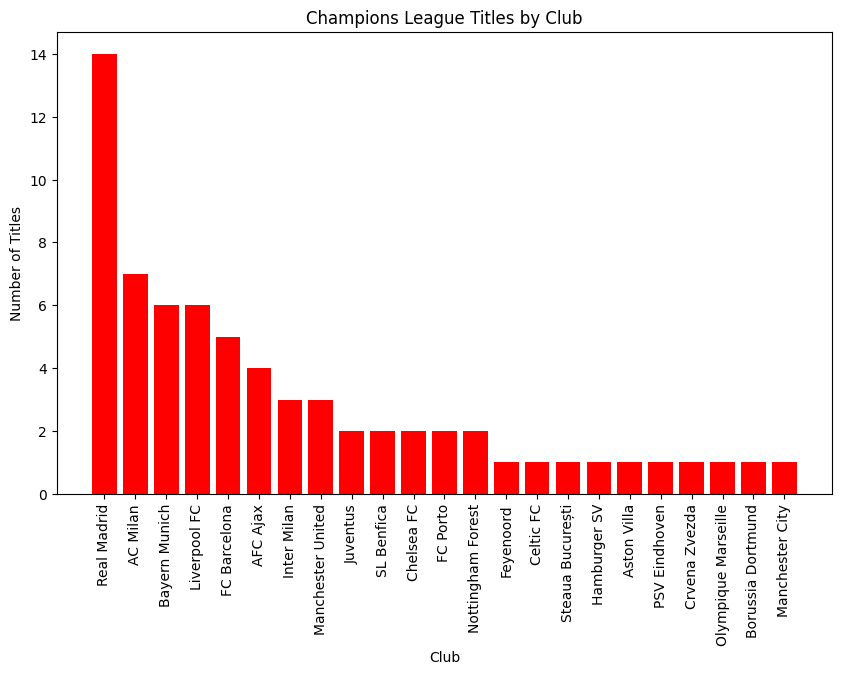

In [22]:
winner_counts=UCL_Finals_df['Winners'].value_counts( )

plt.figure(figsize=(10,6))
plt.bar(winner_counts.index,winner_counts.values,color='red')
plt.xlabel('Club')
plt.ylabel('Number of Titles')
plt.title('Champions League Titles by Club')
plt.xticks(rotation='vertical')
plt.show( )

Observation

Real Madrid has won significantly more Champions League titles than any other club.

Conclusion

Real Madrid is the most successful club in UEFA Champions League history.

Q2. Which clubs have reached the final the most times?

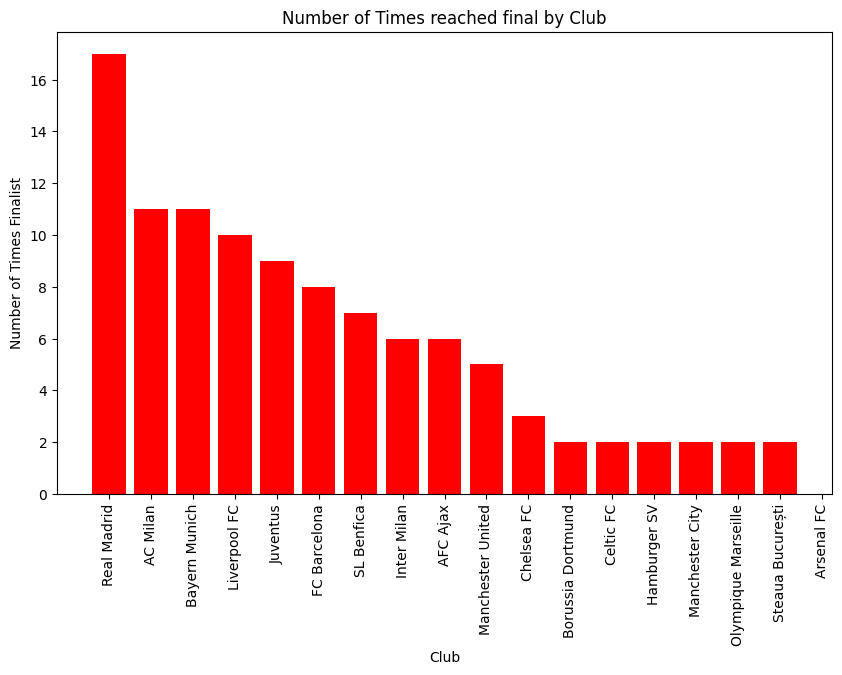

In [23]:
finalist_counts=UCL_Finals_df['Winners'].value_counts( ) + UCL_Finals_df['Runners-up'].value_counts( )
finalist_counts.sort_values( ascending=False, inplace=True)

plt.figure(figsize=(10,6))
plt.bar(finalist_counts.index,finalist_counts.values,color='red')
plt.xlabel('Club')
plt.ylabel('Number of Times Finalist')
plt.title('Number of Times reached final by Club')
plt.xticks(rotation='vertical')
plt.show( )

Observation

Real Madrid has reached the UEFA Champions League final 17 times, which is the highest among all clubs. AC Milan and Bayern Munich are among the next most frequent finalists.

Conclusion

Real Madrid has been the most consistent club in Champions League history, reaching the final more times than any other team. This reflects their long-term dominance and sustained success in the competition.

Q3. Which club has the highest winning percentage in finals?

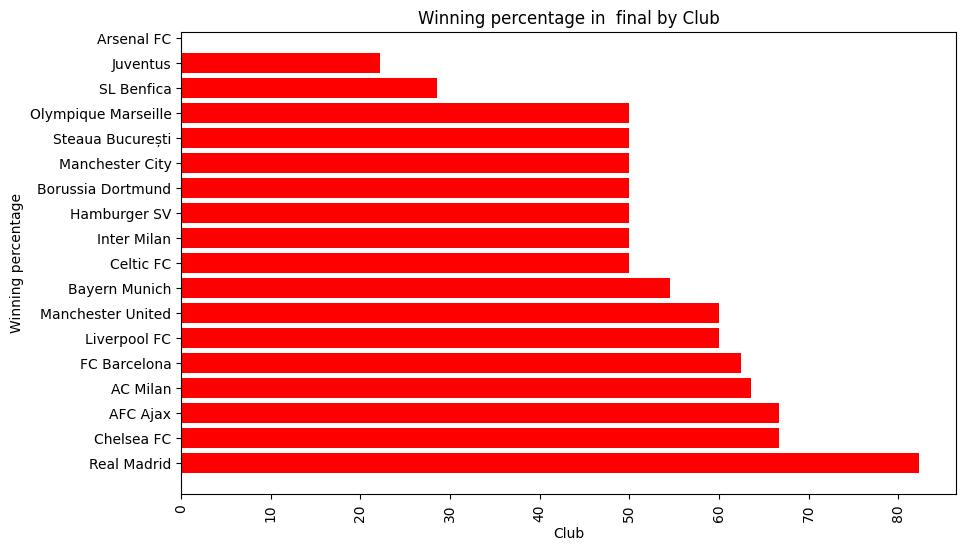

In [24]:
winner_counts = UCL_Finals_df['Winners'].value_counts()
winning_percentage=(winner_counts/finalist_counts)*100
winning_percentage.sort_values(ascending=False,inplace=True)

plt.figure(figsize=(10,6))
plt.barh(winning_percentage.index,winning_percentage.values,color='red')
plt.xlabel('Club')
plt.ylabel('Winning percentage')
plt.title('Winning percentage in  final by Club')
plt.xticks(rotation='vertical')
plt.show( )

Observation

Real Madrid has the highest winning percentage in Champions League finals at 82%. Chelsea, Ajax, and AC Milan also have high winning percentages, indicating that they have been successful whenever they reached the final.

Conclusion

Real Madrid is not only the club with the most Champions League titles and final appearances but also has the highest success rate in finals among the major clubs. This shows that they have consistently performed well in the biggest matches.

Q4. What is the average number of goals scored in a Champions League final?

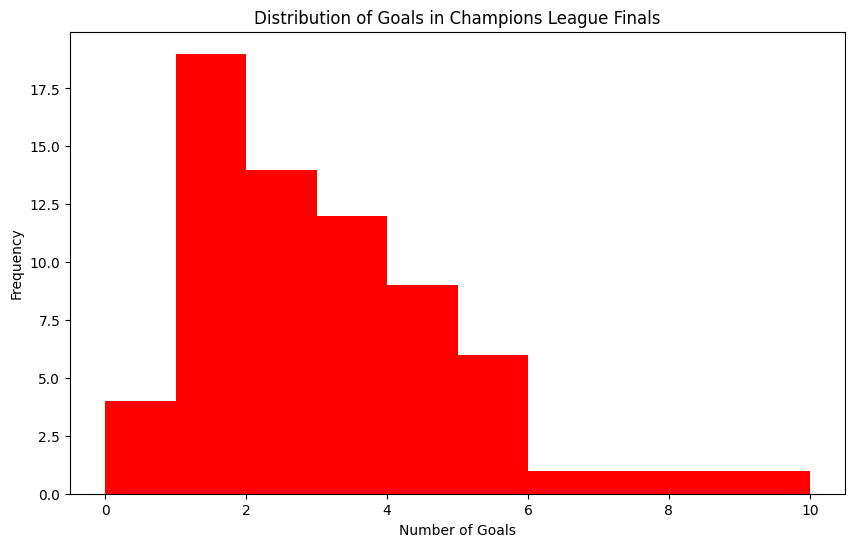

np.float64(2.6470588235294117)

In [25]:
Goals_Finals=UCL_Finals_df['Winner_Goals']+UCL_Finals_df['Runnersup_Goals']

plt.figure(figsize=(10,6))
plt.hist(Goals_Finals,bins=10,color='red')
plt.xlabel('Number of Goals')
plt.ylabel('Frequency')
plt.title('Distribution of Goals in Champions League Finals')
plt.show( )

Goals_Finals.mean( )

Observation

Most Champions League finals had a total of 0 to 6 goals. Finals with very high goal totals were rare, indicating that most matches were relatively low to moderately scoring.

The average number of goals scored per Champions League final was 2.64 goals. Most finals were concentrated between 0 and 6 goals, with only a few matches having unusually high scores.

Q5. Which final had the highest total number of goals?

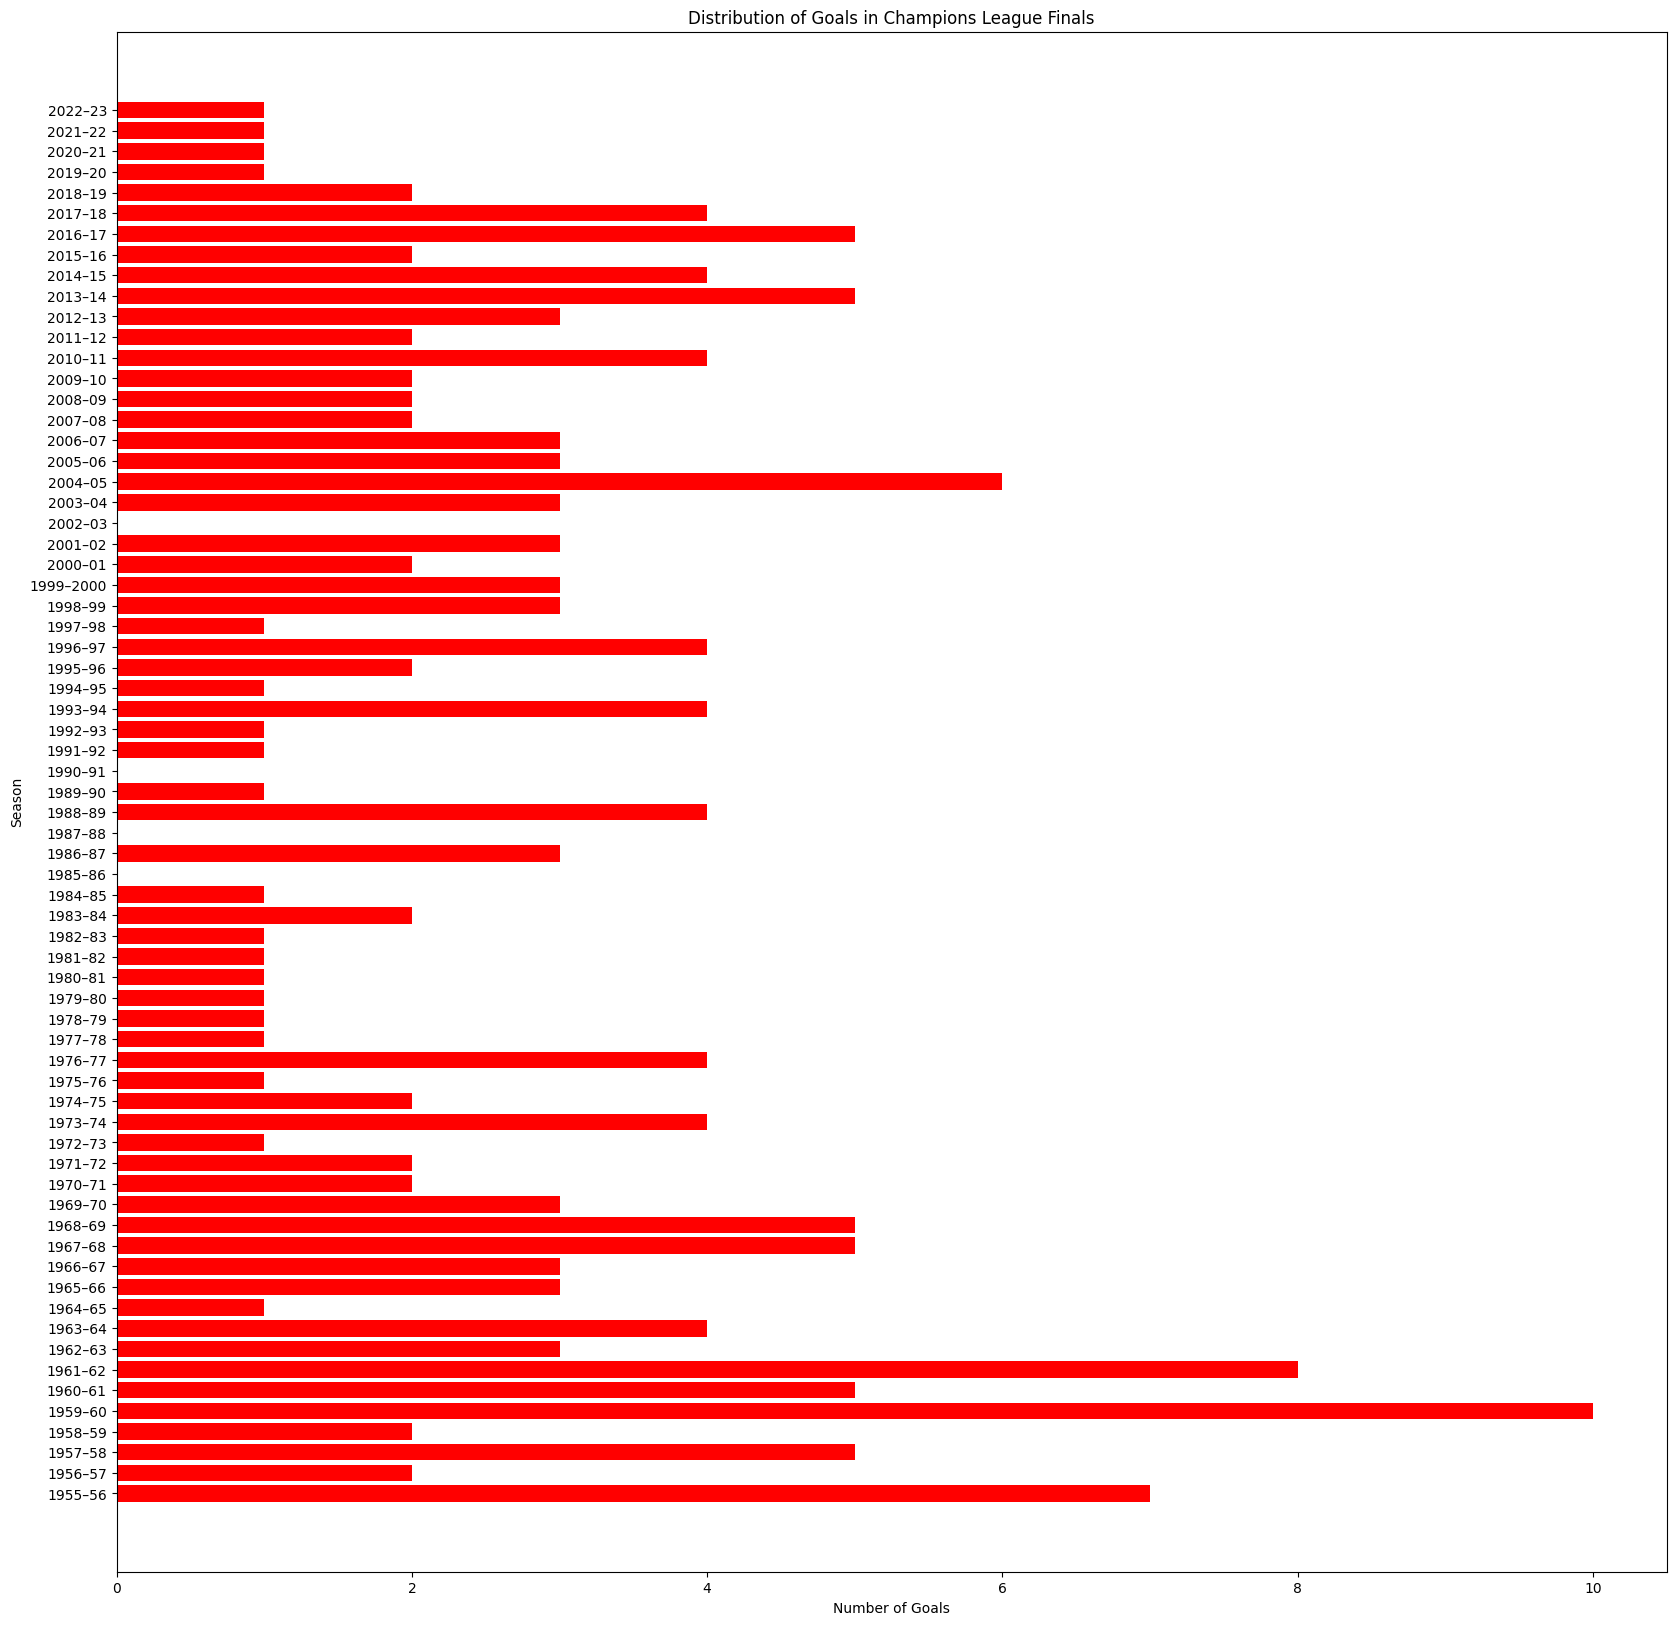

In [26]:
Goals_Finals=UCL_Finals_df['Winner_Goals']+UCL_Finals_df['Runnersup_Goals']

plt.figure(figsize=(20,20))
plt.barh(UCL_Finals_df['Season'],Goals_Finals,color='red')
plt.xlabel('Number of Goals')
plt.ylabel('Season')
plt.title('Distribution of Goals in Champions League Finals')
plt.show( )

Observation

The 1959–60 UEFA Champions League final between Real Madrid and Eintracht Frankfurt had the highest number of goals. Real Madrid won the match 7–3, making it the highest-scoring final in the competition's history with 10 total goals.

Conclusion

The 1959–60 final stands out as one of the most exciting and attacking Champions League finals ever played. It remains a historic match due to the unusually high number of goals scored compared to other finals.

Q6. Which club has played the most Champions League matches?

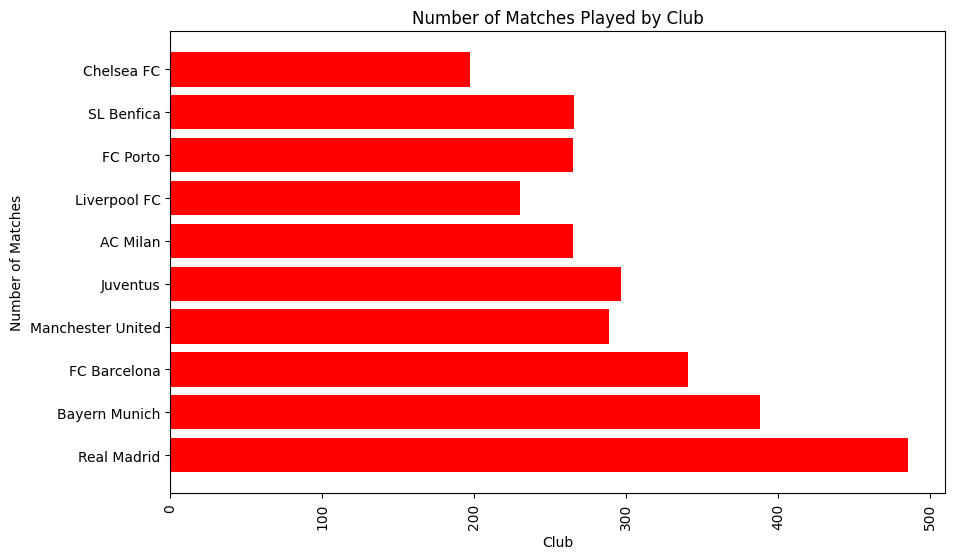

In [27]:
plt.figure(figsize=(10,6))
Top10_teams=UCL_AllTime_df.loc[0:9,'Team']
plt.barh(Top10_teams,UCL_AllTime_df.loc[0:9,'Matches'],color='red')
plt.xlabel('Club')
plt.ylabel('Number of Matches')
plt.title('Number of Matches Played by Club')
plt.xticks(rotation='vertical')
plt.show( )

Observation

Real Madrid has played the highest number of Champions League matches (486), followed by Bayern Munich and Barcelona. These clubs have consistently participated in the competition over many seasons.

Conclusion

Real Madrid has the longest and most consistent presence in Champions League history. Their high number of matches reflects sustained qualification for the tournament and frequent progression to the later stages over many years.

Q7. Which club has the highest win percentage?

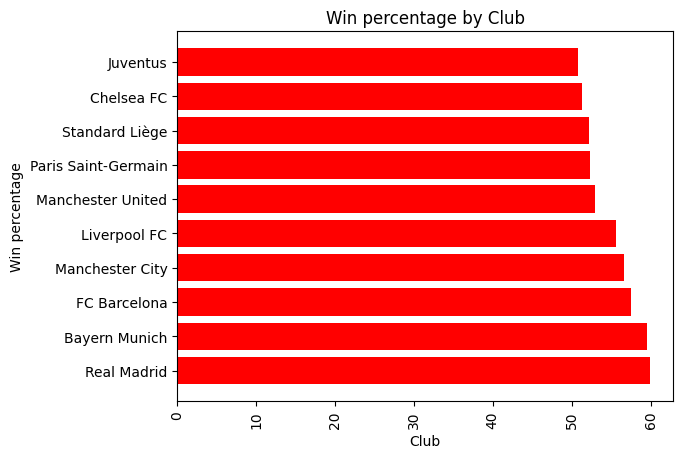

In [28]:
UCL_AllTime_df_1=UCL_AllTime_df[UCL_AllTime_df['Matches']>40]

winning_percentage=(UCL_AllTime_df_1['Wins']/UCL_AllTime_df_1['Matches'])*100
winning_percentage.index=UCL_AllTime_df_1['Team']
winning_percentage.sort_values(ascending=False,inplace=True)

winning_percentage=winning_percentage.head(10)
plt.barh(winning_percentage.index,winning_percentage.values,color='red')
plt.xlabel('Club')
plt.ylabel('Win percentage')
plt.title('Win percentage by Club')
plt.xticks(rotation='vertical')
plt.show( )



Observation

Among clubs that have played at least 40 Champions League matches, Real Madrid has the highest win percentage at approximately 59%. Bayern Munich and Barcelona are close behind, showing consistently high win rates over a large number of matches.

Conclusion

Real Madrid has been the most successful club in terms of winning matches consistently in the Champions League. Bayern Munich and Barcelona have also maintained excellent performance, highlighting their long-term dominance in European football.

Q8. Which club has scored the most goals in Champions League history?


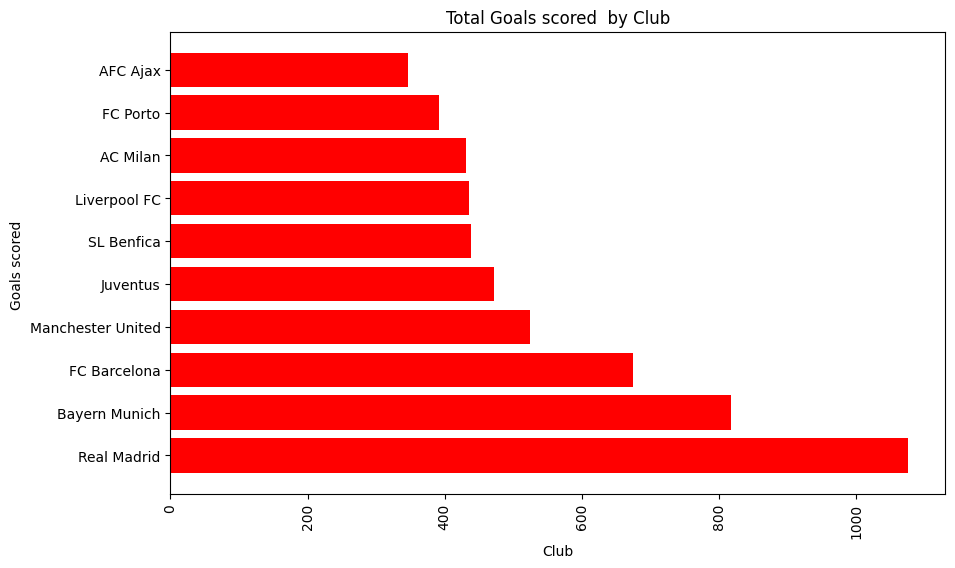

In [29]:
Topscoring_Clubs=UCL_AllTime_df['Goals_scored'].copy()
Topscoring_Clubs.index=UCL_AllTime_df['Team']
Topscoring_Clubs.sort_values(ascending=False,inplace=True)

Topscoring_Clubs=Topscoring_Clubs.head(10)

plt.figure(figsize=(10,6))
plt.barh(Topscoring_Clubs.index,Topscoring_Clubs.values,color='red')
plt.xlabel('Club')
plt.ylabel('Goals scored ')
plt.title('Total Goals scored  by Club')
plt.xticks(rotation='vertical')
plt.show( )


Observation

Real Madrid has scored the highest number of goals in Champions League history with 1,076 goals. Bayern Munich and Barcelona are the next highest-scoring clubs, showing strong attacking records over the years.

Conclusion

Real Madrid has been the most attacking and successful club in Champions League history, scoring more goals than any other team. Bayern Munich and Barcelona have also maintained excellent attacking performances, making them among the strongest offensive clubs in the competition.

Q9. Which club has the highest average goals scored per match?



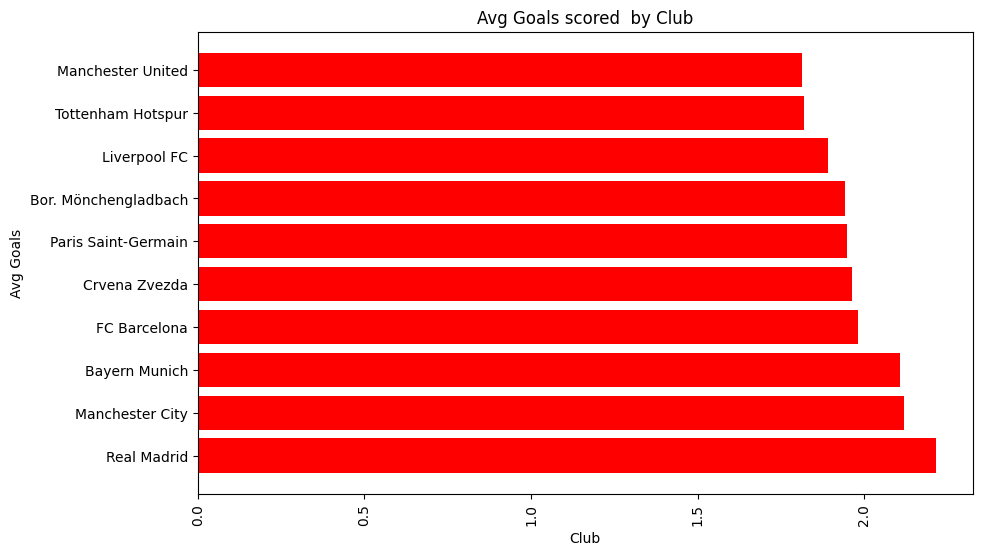

In [30]:
UCL_AllTime_df['Goals_per_match']=UCL_AllTime_df['Goals_scored']/UCL_AllTime_df['Matches']
UCL_AllTime_df_3=UCL_AllTime_df[UCL_AllTime_df['Matches']>40]

UCL_AllTime_df_3=UCL_AllTime_df_3.sort_values(by='Goals_per_match',ascending=False)
UCL_AllTime_df_3=UCL_AllTime_df_3.head(10)

plt.figure(figsize=(10,6))
plt.barh(UCL_AllTime_df_3['Team'],UCL_AllTime_df_3['Goals_per_match'],color='red')
plt.xlabel('Club')
plt.ylabel('Avg Goals')
plt.title('Avg Goals scored  by Club')
plt.xticks(rotation='vertical')
plt.show( )


Observation

Real Madrid has the highest average goals scored per match, with approximately 2.2 goals per game. Manchester City follows closely with 2.1 goals per match, while Bayern Munich ranks third, showing that these clubs have consistently maintained strong attacking performances.

Conclusion

Real Madrid has been the most efficient attacking club in Champions League history, scoring the highest average number of goals per match. Manchester City and Bayern Munich have also demonstrated excellent attacking efficiency, making them among the most dangerous offensive teams in the competition.

Q10.  which club has the best defense?





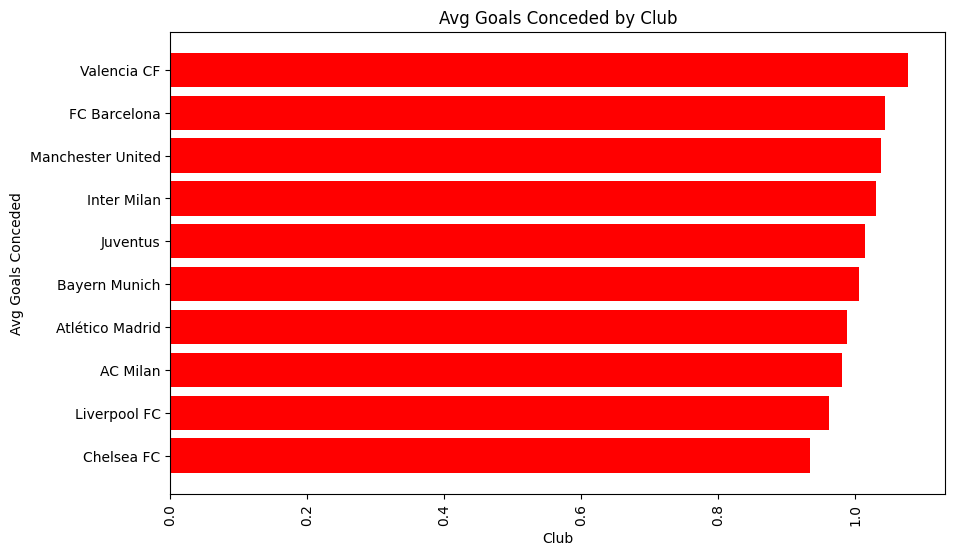

In [31]:
UCL_AllTime_df['Goals_conceded_per_match']=UCL_AllTime_df['Goals_conceded']/UCL_AllTime_df['Matches']
UCL_AllTime_df_4=UCL_AllTime_df[UCL_AllTime_df['Matches']>40]

UCL_AllTime_df_4=UCL_AllTime_df_4.sort_values(by='Goals_conceded_per_match')
UCL_AllTime_df_4=UCL_AllTime_df_4.head(10)

plt.figure(figsize=(10,6))
plt.barh(UCL_AllTime_df_4['Team'],UCL_AllTime_df_4['Goals_conceded_per_match'],color='red')
plt.xlabel('Club')
plt.ylabel('Avg Goals Conceded')
plt.title('Avg Goals Conceded by Club')
plt.xticks(rotation='vertical')
plt.show( )


Observation

Chelsea has the best defensive record, conceding only about 0.93 goals per match on average. Liverpool and AC Milan are the next strongest defensive teams. Real Madrid, despite being one of the most successful and highest-scoring clubs, does not appear in the top 10 for defensive efficiency.

Conclusion

Chelsea has been the most defensively efficient club among the teams analyzed, consistently conceding fewer goals than its competitors. The fact that Real Madrid is not in the top 10 suggests that their historical success has been driven more by their strong attacking ability and overall match-winning performance rather than by having the strongest defense.